In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecg-afib-data/dataset_summary.json
/kaggle/input/ecg-afib-data/y_combined.npy
/kaggle/input/ecg-afib-data/X_combined.npy
/kaggle/input/ecg-afib-data/metadata.csv
/kaggle/input/best-model/best_model.pth


In [2]:
!pip install diffusers transformers wandb accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [3]:
# ============================================================================
# Cell 1: Imports and Setup
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from diffusers import UNet2DConditionModel, DDPMScheduler
from transformers import AutoModel
import wandb
import numpy as np
import os

2025-12-13 16:51:22.295114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765644682.483682      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765644682.534951      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path

# Check PyTorch and CUDA
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Imports complete and seeds set")

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: Tesla T4
CUDA memory: 15.83 GB

✅ Using device: cuda
Imports complete and seeds set


In [5]:
# ============================================================================
# Cell 2: Model Configuration
# ============================================================================


class ModelConfig:
    """Configuration for AFib-ResLSTM model"""
    
    # Input parameters
    INPUT_LENGTH = 2500  # 10 seconds @ 250 Hz
    INPUT_CHANNELS = 1   # Single-lead ECG
    NUM_CLASSES = 2      # Binary: Normal vs AFib
    
    # Multi-scale convolution parameters
    MULTISCALE_FILTERS = [32, 32, 32]  # Filters per branch
    MULTISCALE_KERNELS = [3, 7, 15]    # Different scales
    FUSION_FILTERS = 64
    
    # ResNet backbone parameters
    RESNET_INITIAL_FILTERS = 64
    RESNET_LAYERS = [3, 4, 6, 3]  # ResNet-34 configuration
    RESNET_FILTERS = [64, 128, 256, 512]
    
    # Bi-LSTM parameters
    LSTM_HIDDEN_1 = 128  # First Bi-LSTM layer
    LSTM_HIDDEN_2 = 64   # Second Bi-LSTM layer
    LSTM_LAYERS = 2
    LSTM_DROPOUT = 0.3
    
    # Self-Attention parameters
    ATTENTION_HEADS = 4
    ATTENTION_DIM = 128  # Same as Bi-LSTM output
    
    # Classification head parameters
    FC_HIDDEN = 256
    DROPOUT = 0.5
    
    # Focal Loss parameters (from Petmezas 2021)
    FOCAL_ALPHA = 0.65  # Weight for minority class (AFib)
    FOCAL_GAMMA = 2.0   # Focusing parameter

In [6]:
# ============================================================================
# Cell 3: Multi-Scale Feature Extraction Block
# ============================================================================

class MultiScaleConv1D(nn.Module):
    """
    Multi-scale parallel convolutions to capture features at different scales.
    Innovation #1: Captures P-wave, QRS, and RR intervals simultaneously.
    """
    def __init__(self, in_channels, kernels=[3, 7, 15], filters=[32, 32, 32], fusion_filters=64):
        super(MultiScaleConv1D, self).__init__()
        
        self.branches = nn.ModuleList()
        
        # Create parallel convolution branches
        for kernel, num_filters in zip(kernels, filters):
            branch = nn.Sequential(
                nn.Conv1d(in_channels, num_filters, kernel_size=kernel, padding=kernel//2),
                nn.BatchNorm1d(num_filters),
                nn.ReLU(inplace=True)
            )
            self.branches.append(branch)
        
        # Fusion layer (1x1 convolution)
        total_filters = sum(filters)
        self.fusion = nn.Sequential(
            nn.Conv1d(total_filters, fusion_filters, kernel_size=1),
            nn.BatchNorm1d(fusion_filters),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Apply all branches in parallel
        branch_outputs = [branch(x) for branch in self.branches]
        
        # Concatenate along channel dimension
        concatenated = torch.cat(branch_outputs, dim=1)
        
        # Fuse features
        fused = self.fusion(concatenated)
        
        return fused


In [7]:
# ============================================================================
# Cell 4: 1D ResNet Building Blocks
# ============================================================================

class ResidualBlock1D(nn.Module):
    """
    Basic Residual Block for 1D signals (ECG)
    """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock1D, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.downsample = downsample
        
    def forward(self, x):
        identity = x
        
        # First conv block
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # Second conv block
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Downsample identity if needed (for skip connection)
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection
        out += identity
        out = self.relu(out)
        
        return out


In [8]:
class ResNetBackbone1D(nn.Module):
    """
    1D ResNet-34 backbone for ECG feature extraction
    Based on: Jia et al. 2020, Ben-Moshe et al. 2023
    """
    def __init__(self, in_channels=64, layers=[3, 4, 6, 3], filters=[64, 128, 256, 512]):
        super(ResNetBackbone1D, self).__init__()
        
        self.in_channels = in_channels
        
        # Initial convolution (already done by multi-scale, so this is identity)
        # We'll start from the multi-scale output (64 channels)
        
        # ResNet stages
        self.layer1 = self._make_layer(filters[0], layers[0], stride=1)
        self.layer2 = self._make_layer(filters[1], layers[1], stride=2)
        self.layer3 = self._make_layer(filters[2], layers[2], stride=2)
        self.layer4 = self._make_layer(filters[3], layers[3], stride=2)
        
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        
        # If dimensions change, create downsample path
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(self.in_channels, out_channels, kernel_size=1, 
                         stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        layers = []
        # First block (may downsample)
        layers.append(ResidualBlock1D(self.in_channels, out_channels, stride, downsample))
        
        self.in_channels = out_channels
        
        # Remaining blocks
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Pass through ResNet stages
        x = self.layer1(x)  # Output: (batch, 64, length)
        x = self.layer2(x)  # Output: (batch, 128, length/2)
        x = self.layer3(x)  # Output: (batch, 256, length/4)
        x = self.layer4(x)  # Output: (batch, 512, length/8)
        
        # Global pooling
        pooled = self.avgpool(x).squeeze(-1)  # (batch, 512)
        
        return x, pooled  # Return both sequence and pooled features


In [9]:
# ============================================================================
# Cell 5: Multi-Head Self-Attention Mechanism
# ============================================================================

class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention for temporal feature weighting.
    Innovation #2: Identifies critical time segments + provides interpretability.
    """
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super(MultiHeadSelfAttention, self).__init__()
        
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        # Linear projections for Q, K, V
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        
        # Output projection
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5
        
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, embed_dim)
        Returns:
            attended: (batch, seq_len, embed_dim)
            attention_weights: (batch, num_heads, seq_len, seq_len)
        """
        batch_size, seq_len, embed_dim = x.shape
        
        # Linear projections and reshape for multi-head
        Q = self.query(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Scaled dot-product attention
        # (batch, heads, seq_len, head_dim) x (batch, heads, head_dim, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # Apply attention to values
        attended = torch.matmul(attention_weights, V)
        
        # Reshape back
        attended = attended.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        
        # Output projection
        output = self.out_proj(attended)
        
        return output, attention_weights

In [10]:
# ============================================================================
# Cell 6: Bidirectional LSTM with Self-Attention
# ============================================================================

class BiLSTMWithAttention(nn.Module):
    """
    Bidirectional LSTM with multi-head self-attention for temporal modeling.
    Combines ideas from Andersen 2019, Jia 2020, with attention innovation.
    """
    def __init__(self, input_size, hidden_1=128, hidden_2=64, num_heads=4, dropout=0.3):
        super(BiLSTMWithAttention, self).__init__()
        
        # First Bi-LSTM layer
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_1,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.0  # No dropout for single layer
        )
        
        # Second Bi-LSTM layer
        self.lstm2 = nn.LSTM(
            input_size=hidden_1 * 2,  # *2 for bidirectional
            hidden_size=hidden_2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.0
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # Self-attention (applied to LSTM output)
        attention_dim = hidden_2 * 2  # *2 for bidirectional
        self.attention = MultiHeadSelfAttention(
            embed_dim=attention_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        
        # Final dimension
        self.output_dim = hidden_2 * 2
        
    def forward(self, x):
        """
        Args:
            x: (batch, channels, length) - from ResNet
        Returns:
            attended_output: (batch, hidden_2 * 2)
            attention_weights: for visualization
        """
        # Reshape for LSTM: (batch, seq_len, features)
        x = x.transpose(1, 2)  # (batch, length, channels)
        
        # First Bi-LSTM
        lstm1_out, _ = self.lstm1(x)
        lstm1_out = self.dropout(lstm1_out)
        
        # Second Bi-LSTM
        lstm2_out, _ = self.lstm2(lstm1_out)
        lstm2_out = self.dropout(lstm2_out)
        
        # Apply self-attention
        attended, attention_weights = self.attention(lstm2_out)
        
        # Global average pooling over time
        pooled = torch.mean(attended, dim=1)  # (batch, hidden_2 * 2)
        
        return pooled, attention_weights


In [11]:
# ============================================================================
# Cell 7: Complete AFib-ResLSTM Architecture
# ============================================================================

class AFibResLSTM(nn.Module):
    """
    AFib-ResLSTM: Multi-Scale ResNet + Bi-LSTM + Self-Attention
    
    Innovations:
    1. Multi-scale parallel convolutions (captures P-wave, QRS, RR intervals)
    2. Self-attention on Bi-LSTM output (interpretable + performance boost)
    3. Hybrid feature fusion (ResNet morphology + LSTM-Attention temporal)
    
    Architecture inspired by:
    - Jia et al. 2020 (ResNet-LSTM hybrid)
    - Petmezas et al. 2021 (focal loss for imbalance)
    - Ben-Moshe et al. 2023 (deep residual + BiGRU)
    + Your novel contributions
    """
    def __init__(self, config):
        super(AFibResLSTM, self).__init__()
        
        self.config = config
        
        # BLOCK 1: Multi-Scale Feature Extraction
        self.multiscale = MultiScaleConv1D(
            in_channels=config.INPUT_CHANNELS,
            kernels=config.MULTISCALE_KERNELS,
            filters=config.MULTISCALE_FILTERS,
            fusion_filters=config.FUSION_FILTERS
        )
        
        # BLOCK 2: ResNet-34 Backbone
        self.resnet = ResNetBackbone1D(
            in_channels=config.FUSION_FILTERS,
            layers=config.RESNET_LAYERS,
            filters=config.RESNET_FILTERS
        )
        
        # BLOCK 3: Bi-LSTM with Self-Attention
        self.bilstm_attention = BiLSTMWithAttention(
            input_size=config.RESNET_FILTERS[-1],
            hidden_1=config.LSTM_HIDDEN_1,
            hidden_2=config.LSTM_HIDDEN_2,
            num_heads=config.ATTENTION_HEADS,
            dropout=config.LSTM_DROPOUT
        )
        
        # BLOCK 4: Adaptive Decision Head (Hybrid Feature Fusion)
        # Concatenate ResNet pooled features + LSTM-Attention features
        fusion_dim = config.RESNET_FILTERS[-1] + (config.LSTM_HIDDEN_2 * 2)
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, config.FC_HIDDEN),
            nn.ReLU(inplace=True),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.FC_HIDDEN, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(config.DROPOUT),
            nn.Linear(128, config.NUM_CLASSES)
        )
        
    def forward(self, x):
        """
        Args:
            x: (batch, 1, 2500) - Raw ECG signal
        Returns:
            logits: (batch, 2) - Class logits
            attention_weights: (batch, heads, seq_len, seq_len) - For visualization
        """
        # Multi-scale feature extraction
        multiscale_features = self.multiscale(x)  # (batch, 64, 2500)
        
        # ResNet backbone
        resnet_seq, resnet_pooled = self.resnet(multiscale_features)
        # resnet_seq: (batch, 512, ~312)
        # resnet_pooled: (batch, 512)
        
        # Bi-LSTM with attention
        lstm_features, attention_weights = self.bilstm_attention(resnet_seq)
        # lstm_features: (batch, 128)
        
        # Hybrid feature fusion
        fused_features = torch.cat([resnet_pooled, lstm_features], dim=1)
        # fused_features: (batch, 512 + 128 = 640)
        
        # Classification
        logits = self.classifier(fused_features)  # (batch, 2)
        
        return logits, attention_weights
    
    def get_attention_maps(self, x):
        """
        Extract attention weights for visualization (XAI Phase 2)
        """
        with torch.no_grad():
            _, attention_weights = self.forward(x)
        return attention_weights


In [12]:
# ============================================================================
# Cell 8: Focal Loss for Class Imbalance (Petmezas et al. 2021)
# ============================================================================

class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance in AFib detection.
    
    Reference: Petmezas et al. 2021 - achieved Sp=99.29% with focal loss
    
    Formula: FL(pt) = -α(1-pt)^γ * log(pt)
    
    Args:
        alpha: Weight for positive class (AFib). Set to ~0.65 for your 35.6% AFib data
        gamma: Focusing parameter. Higher gamma = more focus on hard examples
    """
    def __init__(self, alpha=0.65, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch, num_classes) - Raw model outputs
            targets: (batch,) - Class indices (0 or 1)
        """
        # Get probabilities
        probs = F.softmax(logits, dim=1)
        
        # Get probability of true class
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        pt = (probs * targets_one_hot).sum(dim=1)  # Probability of true class
        
        # Focal loss formula
        focal_weight = (1 - pt) ** self.gamma
        
        # Apply alpha weighting
        alpha_weight = targets_one_hot[:, 1] * self.alpha + targets_one_hot[:, 0] * (1 - self.alpha)
        
        # Cross-entropy loss
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        
        # Final focal loss
        focal_loss = alpha_weight * focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [13]:
# ============================================================================
# DEFINE THE DATASET CLASS
# ============================================================================

class PreprocessedDataset(Dataset):
    def __init__(self, x_path):
        self.signals = np.load(x_path)
        # Normalize
        self.signals = (self.signals - np.mean(self.signals, axis=1, keepdims=True)) / (np.std(self.signals, axis=1, keepdims=True) + 1e-6)

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        # Convert to float32 and add channel dim [1, 2500]
        return torch.tensor(self.signals[idx], dtype=torch.float32).unsqueeze(0)

In [14]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# STYLE ENCODER
class StyleEncoderWrapper(nn.Module):
    def __init__(self, weights_path):
        super().__init__()
        config = ModelConfig()
        self.brain = AFibResLSTM(config).to(DEVICE)

        # Load weights
        checkpoint = torch.load(weights_path, map_location=DEVICE)
        if 'model_state_dict' in checkpoint:
            self.brain.load_state_dict(checkpoint['model_state_dict'])
        else:
            self.brain.load_state_dict(checkpoint)

        # Remove classifier
        self.brain.classifier = nn.Sequential(*list(self.brain.classifier.children())[:5])
        self.brain.eval()
        for param in self.brain.parameters():
            param.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            return self.brain(x)[0]

# CONTENT ENCODER
class PretrainedContentEncoder(nn.Module):
    def __init__(self, model_name="Edoardo-BS/hubert-ecg-base", out_dim=512):
        super().__init__()
        print(f"Loading Pretrained ECG Content Encoder: {model_name}")
        self.net = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Freeze weights so we don't break the medical knowledge
        for param in self.net.parameters():
            param.requires_grad = False 

        # Projector: The model outputs 768 features, we need 512 for U-Net
        self.proj = nn.Linear(768, out_dim)

    def forward(self, x):
        # x comes in as [Batch, 1, 2500] or [Batch, 1, 1, 2500]
        
        # 1. FLATTEN to [Batch, 2500]
        # This removes ALL channel dimensions (1s) and leaves just the raw signal.
        # It's like unboxing the data so the model can read it directly.
        x = x.reshape(x.shape[0], -1) 
        
        # 2. Pass directly to model
        # The model expects [Batch, Sequence_Length], which is exactly [16, 2500]
        outputs = self.net(x)

        # 3. Extract features
        features = outputs.last_hidden_state
        return self.proj(features)

In [15]:
import os
import wandb

# PASTE YOUR KEY INSIDE THE QUOTES BELOW
os.environ["WANDB_API_KEY"] = "c9ad7c37426c5b72128b923af50ee87a44014fd1"
wandb.login()

wandb: Currently logged in as: e20189 (e20189-university-of-peradeniya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [16]:
def train():
    # print("Helloooo")
    wandb.init(project="Kaggle-ECG-Generation")

    dataset_path = "/kaggle/input/ecg-afib-data/X_combined.npy"
    weights_path = "/kaggle/input/best-model/best_model.pth"

    # Load Data
    ds = PreprocessedDataset(dataset_path)
    loader = DataLoader(ds, batch_size=32, shuffle=True, num_workers=2)

    # Initialize Models
    style_net = StyleEncoderWrapper(weights_path).to(DEVICE)
    content_net = PretrainedContentEncoder().to(DEVICE)
    unet = UNet2DConditionModel(
        sample_size=(1,64),
        in_channels=1,
        out_channels=1,
        cross_attention_dim=512,
        block_out_channels=(64, 128, 256, 512),
        down_block_types=("DownBlock2D", "CrossAttnDownBlock2D", "CrossAttnDownBlock2D", "DownBlock2D"),
        up_block_types=("UpBlock2D", "CrossAttnUpBlock2D", "CrossAttnUpBlock2D", "UpBlock2D"),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
    scheduler = DDPMScheduler(num_train_timesteps=1000)

    print("Training Started on Kaggle GPU...")

    for epoch in range(50):
        unet.train()
        for batch in loader:
            x = batch.to(DEVICE)
            with torch.no_grad():
                style = style_net(x)
                content = content_net(x)

            noise = torch.randn_like(x)
            t = torch.randint(0, 1000, (x.shape[0],), device=DEVICE).long()
            noisy_x = scheduler.add_noise(x.unsqueeze(2), noise.unsqueeze(2), t)

            pred = unet(noisy_x, t, encoder_hidden_states=content).sample
            loss = F.mse_loss(pred, noise.unsqueeze(2))

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            torch.cuda.empty_cache()
            wandb.log({"loss": loss.item()})

        print(f"Epoch {epoch} Done")
        # Save output to /kaggle/working/ so you can download it later
        if epoch % 1 == 0:
            unet.save_pretrained(f"/kaggle/working/model_epoch_{epoch}")

In [17]:
train()

Loading Pretrained ECG Content Encoder: Edoardo-BS/hubert-ecg-base


config.json: 0.00B [00:00, ?B/s]

hubert_ecg.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Edoardo-BS/hubert-ecg-base:
- hubert_ecg.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/373M [00:00<?, ?B/s]

Training Started on Kaggle GPU...
Epoch 0 Done
Epoch 1 Done
Epoch 2 Done


KeyboardInterrupt: 

In [22]:
# --- RE-INITIALIZE THE MISSING PIECES ---

print("Restoring helper models...")

# 1. Define Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Re-create the Content Encoder
# (This downloads the config again, which is fast)
content_net = PretrainedContentEncoder().to(DEVICE)

# 3. Re-create the Style Encoder
# (Make sure this path matches your Kaggle input path)
weights_path = "/kaggle/input/best-model/best_model.pth" 
style_net = StyleEncoderWrapper(weights_path).to(DEVICE)

# 4. Re-create the Scheduler
# (Crucial for the diffusion process)
scheduler = DDPMScheduler(num_train_timesteps=1000)

print("✅ Restoration Complete. Now run the Plotting Code again!")

🔧 Restoring helper models...
Loading Pretrained ECG Content Encoder: Edoardo-BS/hubert-ecg-base
✅ Restoration Complete. Now run the Plotting Code again!


Loading your saved model...
Painting a new ECG...


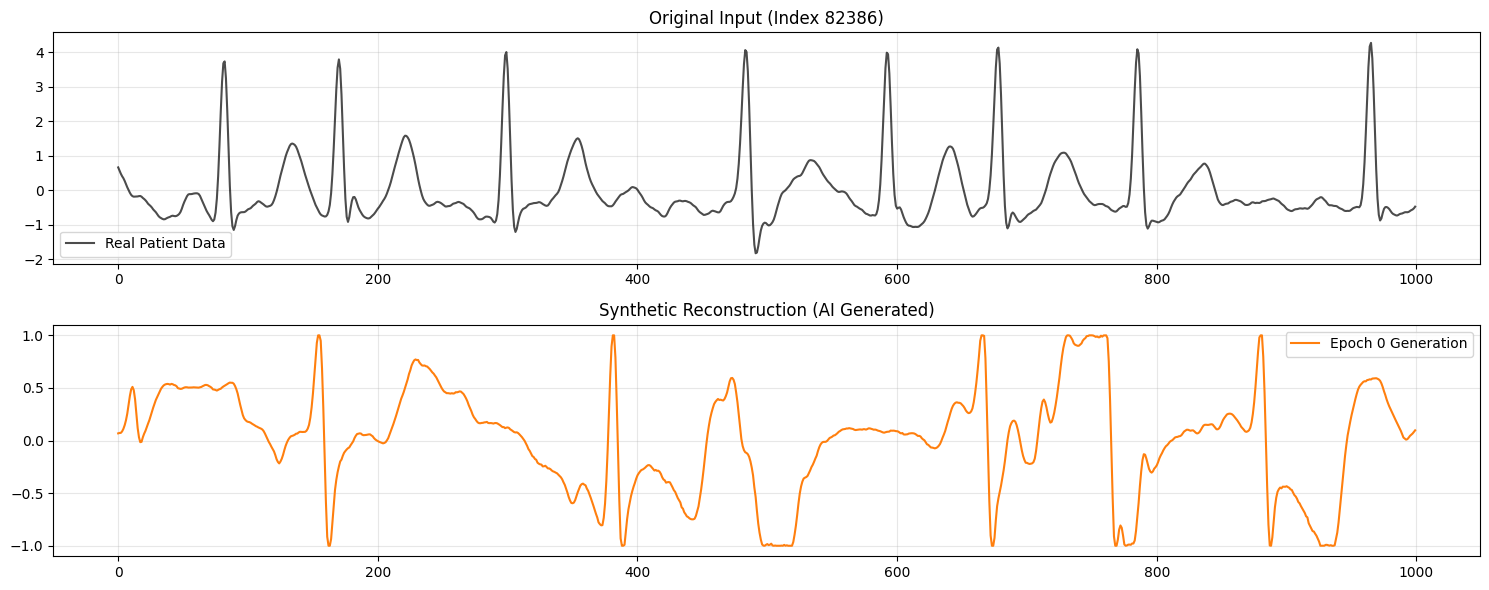

In [27]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the "Epoch 0" Brain
print("Loading your saved model...")
unet_path = "/kaggle/working/model_epoch_0"
unet = UNet2DConditionModel.from_pretrained(unet_path).to(DEVICE)
unet.eval()

# 2. Define the Generation Function
def generate_counterfactual(real_ecg_tensor, target_style_tensor):
    # real_ecg_tensor comes in as [1, 1, 2500]
    
    # 1. Get Content (This part works fine with 3D input)
    with torch.no_grad():
        content_emb = content_net(real_ecg_tensor)
    
    # 2. Setup Noise in 4D SHAPE [Batch, Channels, Height=1, Width=2500]
    noise = torch.randn(1, 1, 1, 2500).to(DEVICE)
    
    # Setup Scheduler
    unet.config.num_train_timesteps = 1000
    scheduler.set_timesteps(50) 
    
    print("Painting a new ECG...")
    for t in scheduler.timesteps:
        with torch.no_grad():
            # Now the input 'noise' is 4D, which is what unet wants 
            model_output = unet(noise, t, encoder_hidden_states=content_emb).sample
            
            # Remove noise
            noise = scheduler.step(model_output, t, noise).prev_sample

    # 3. Return to normal shape [1, 1, 2500]
    return noise.squeeze(2)

# --- RE-RUN THE PLOT ---
# Pick a random real signal
ds_test = PreprocessedDataset("/kaggle/input/ecg-afib-data/X_combined.npy")
idx = np.random.randint(len(ds_test))
real_sample = ds_test[idx].unsqueeze(0).to(DEVICE) 

# Generate!
synthetic_sample = generate_counterfactual(real_sample, None)

# Plot Results
real_data = real_sample.cpu().squeeze().numpy()
fake_data = synthetic_sample.cpu().squeeze().numpy()

plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(real_data[:1000], color='black', alpha=0.7, label='Real Patient Data')
plt.title(f"Original Input (Index {idx})")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(fake_data[:1000], color='#ff7f0e', linewidth=1.5, label='Epoch 0 Generation')
plt.title("Synthetic Reconstruction (AI Generated)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Loading AFibResLSTM Classifier...
✅ Classifier loaded successfully!

Selected Index: 44131
Ground Truth Label: Normal
Painting a new ECG...


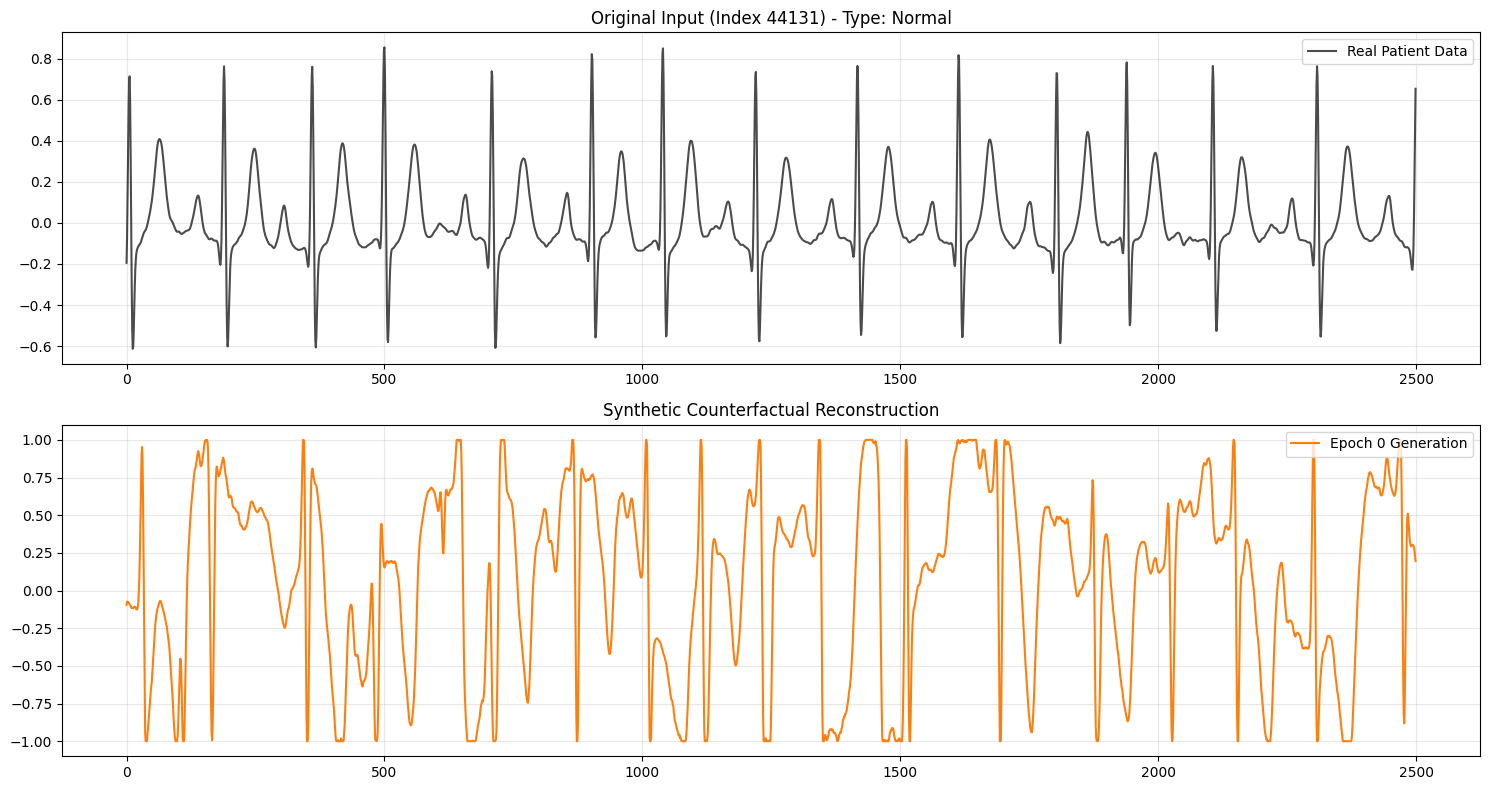

----------------------------------------
>>> 🧠 CLASSIFIER DIAGNOSIS
----------------------------------------
Original Label       : Normal
AI Generated Signal  : AFib
AFib Confidence      : 65.93%
----------------------------------------
🚀 SUCCESS: The model successfully FLIPPED the class!
----------------------------------------


In [39]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSIFIER_PATH = "/kaggle/input/best-model/best_model.pth"
DATA_PATH_X = "/kaggle/input/ecg-afib-data/X_combined.npy"
DATA_PATH_Y = "/kaggle/input/ecg-afib-data/y_combined.npy"

# --- STEP 1: LOAD THE CORRECT JUDGE (AFibResLSTM) ---
# We use the class already defined in your notebook (Cell 11)
print("Loading AFibResLSTM Classifier...")
config = ModelConfig() # Uses the config from Cell 2
classifier = AFibResLSTM(config).to(DEVICE)

# Load the weights
checkpoint = torch.load(CLASSIFIER_PATH, map_location=DEVICE)
if 'model_state_dict' in checkpoint:
    classifier.load_state_dict(checkpoint['model_state_dict'])
else:
    classifier.load_state_dict(checkpoint)

classifier.eval() # Freeze for judging
print("✅ Classifier loaded successfully!")

# --- STEP 2: PICK RANDOM SAMPLE ---
X_data = np.load(DATA_PATH_X)
y_data = np.load(DATA_PATH_Y)

idx = np.random.randint(len(X_data))

# Prepare Input (Batch=1, Channels=1, Length=2500)
# Note: Your model config expects input length 2500
real_sample_np = X_data[idx] 
real_sample = torch.tensor(real_sample_np).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

# Get Truth Label
original_label_code = y_data[idx]
original_label_str = "AFib" if original_label_code == 1 else "Normal"

print(f"\nSelected Index: {idx}")
print(f"Ground Truth Label: {original_label_str}")

# --- STEP 3: GENERATE COUNTERFACTUAL ---
# Using your Epoch 0 generator
with torch.no_grad():
    synthetic_sample = generate_counterfactual(real_sample, None)

# --- STEP 4: VISUALIZE ---
real_plot = real_sample.cpu().squeeze().numpy()
fake_plot = synthetic_sample.cpu().squeeze().numpy()

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(real_plot, color='black', alpha=0.7, label=f'Real Patient Data')
plt.title(f"Original Input (Index {idx}) - Type: {original_label_str}")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(fake_plot, color='#ff7f0e', linewidth=1.5, label='Epoch 0 Generation')
plt.title("Synthetic Counterfactual Reconstruction")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- STEP 5: THE CLASSIFIER JUDGMENT ---
print("-" * 40)
print(">>> 🧠 CLASSIFIER DIAGNOSIS")
print("-" * 40)

with torch.no_grad():
    # The AFibResLSTM returns (logits, attention_weights)
    logits, attn_weights = classifier(synthetic_sample)
    
    # Convert logits to probabilities (Softmax for binary 2-class)
    probs = F.softmax(logits, dim=1)
    
    # Get probability of AFib (Class 1)
    afib_prob = probs[0, 1].item()

predicted_str = "AFib" if afib_prob > 0.5 else "Normal"

print(f"Original Label       : {original_label_str}")
print(f"AI Generated Signal  : {predicted_str}")
print(f"AFib Confidence      : {afib_prob*100:.2f}%")

print("-" * 40)
if original_label_str != predicted_str:
    print("🚀 SUCCESS: The model successfully FLIPPED the class!")
else:
    print("⚠️ STATUS: No class flip yet (Expected for Epoch 0).")
print("-" * 40)

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_attention_overlay(model, ecg_sample, title="Model Attention Map"):
    """
    ecg_sample: A numpy array of shape (1000,) or (1, 1000) representing 10s of data.
    model: Your trained BiLSTM+Attention model.
    """
    
    # 1. Prepare Data
    model.eval()
    if len(ecg_sample.shape) == 1:
        # Add batch and channel dimensions if missing: (1, 1, 1000) or (1, 1000)
        # Adjust based on your model's expected input (Sequence Last vs Sequence First)
        tensor_data = torch.tensor(ecg_sample).float().unsqueeze(0).unsqueeze(0) 
    else:
        tensor_data = torch.tensor(ecg_sample).float()

    # 2. Forward Pass (Get the weights)
    # *CRITICAL*: Ensure your model's forward() returns (output, attention_weights)
    # If your model only returns output, modify the forward() temporarily to return both.
    with torch.no_grad():
        _, attn_weights = model(tensor_data)
    
    # 3. Process Weights
    # Attention weights usually come out as shape (Batch, Seq_Len, 1) or (Batch, Seq_Len)
    # We flatten them to match the 1D signal
    attn_weights = attn_weights.cpu().numpy().flatten()
    signal = ecg_sample.flatten()

    # Interpolate weights if sizes don't match 
    # (e.g., if LSTM output was pooled/reduced, resize attention mask to 1000)
    if len(attn_weights) != len(signal):
        attn_weights = np.interp(
            np.linspace(0, 1, len(signal)), 
            np.linspace(0, 1, len(attn_weights)), 
            attn_weights
        )

    # 4. Normalize Weights for Visualization (Min-Max Scaling)
    # This makes the "red" parts pop, even if raw attention scores are small
    attn_weights = (attn_weights - attn_weights.min()) / (attn_weights.max() - attn_weights.min())

    # 5. Plotting
    plt.figure(figsize=(12, 4))
    
    # We plot the line as a scatter plot of dense points to allow color variation per point
    # (Or use LineCollection for better performance, but scatter is easier to write/debug)
    plt.scatter(range(len(signal)), signal, c=attn_weights, cmap='inferno_r', s=2)
    
    # Add a colorbar to explain the "Heat"
    cbar = plt.colorbar()
    cbar.set_label('Model Attention (Importance)')
    
    plt.title(title)
    plt.xlabel("Time (ms)")
    plt.ylabel("Normalized Amplitude")
    plt.grid(True, alpha=0.3)
    plt.show()

# Example Usage:
# plot_attention_overlay(my_bilstm_model, my_ecg_data[0], title="Why is this AFib?")